# Data Visualization Ethics Challenge

In this activity, you’ll work with a simple dataset and examine two deliberately bad charts.  
Each one ignores multiple best practices for ethical and effective visualization.

Your job is to:

1. Review each chart and note at least three issues you see.  
2. Create a new chart (or charts) that present the data clearly, accurately, and honestly.  
3. Include clear labels, a cited data source, and a descriptive but neutral title.

**Remember:** Strong visualizations tell the truth, provide context, and avoid design choices that distort or mislead.


## Step 1: Load the dataset

We’re using a provided CSV file with fictional sales data for a coffee chain.  
No need to modify anything in this cell — just run it so the dataset loads into your notebook.  
Once loaded, take a quick look at the first few rows to get familiar with the columns and values.


In [98]:
import pandas as pd
import matplotlib.pyplot as plt

coffee_df = pd.read_csv("fake_coffee_chain_sales.csv")
coffee_df.head()

,Year,Month,Region,Category,Sales,Profit
0,2020,January,East,Espresso,14724,5290.46
1,2020,January,East,Lattes,11948,4138.77
2,2020,January,East,Tea,18660,5959.44
3,2020,January,East,Pastries,11265,2604.46
4,2020,January,East,Beans,8954,2613.22


## Step 2: Review the BAD Charts

Below are two deliberately poor visualizations.  
Your task: Carefully review each and take notes on what you think is wrong, misleading, or just poorly designed.  
Think about chart type, colors, scales, labeling, and whether the chart tells the truth.  


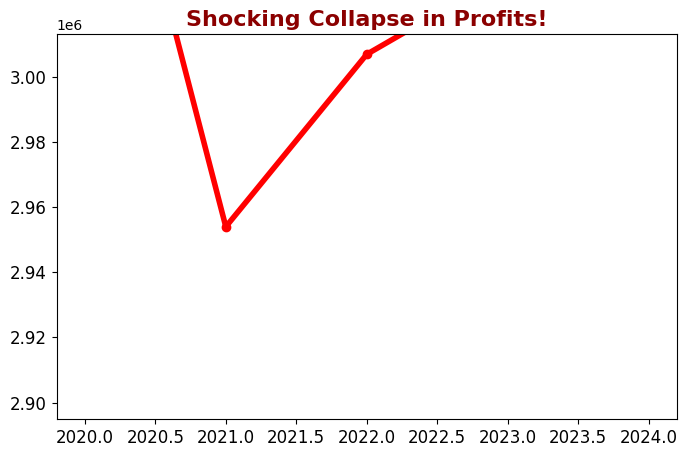

In [19]:
plt.figure(figsize=(8,5))
subset = coffee_df.groupby("Year")["Sales"].sum().reset_index()

# Wrong variable for title, truncated y-axis, misleading color & framing
plt.plot(subset["Year"], subset["Sales"], color="red", linewidth=4, marker="o")
plt.ylim(subset["Sales"].min() * 0.98, subset["Sales"].min() * 1.02)  # extreme truncation
plt.title("Shocking Collapse in Profits!", fontsize=16, fontweight="bold", color="darkred")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


### Write your notes about bad chart #1 here:
- There is no label on the y-axis
- Y-axis does not start at 0
- The colors and title are alarmist / inflammatory
- It looks like the data shown is sales, not profit

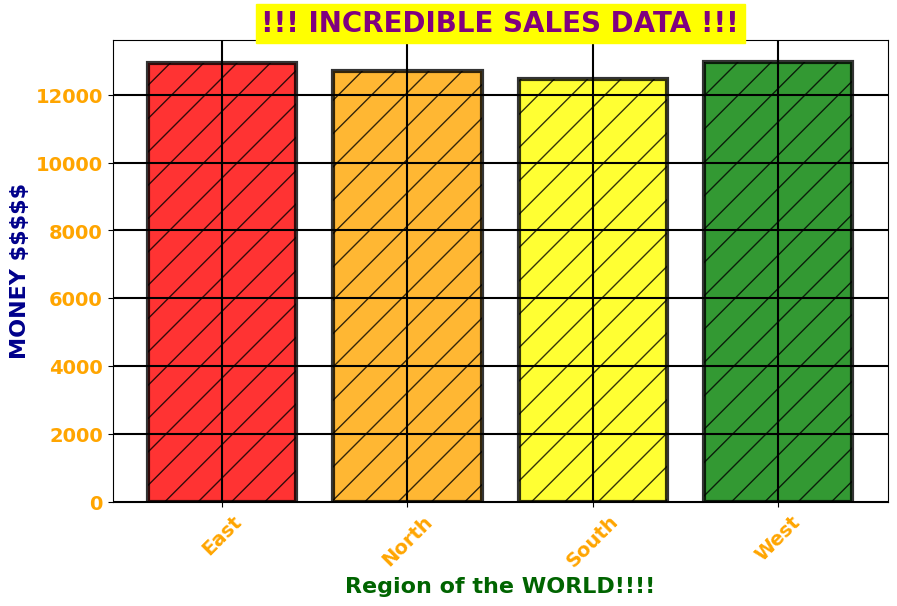

In [10]:
plt.figure(figsize=(10,6))
avg_sales = coffee_df.groupby("Region")["Sales"].mean().reset_index()

colors = ["red","orange","yellow","green","blue","purple"]

plt.bar(avg_sales["Region"], avg_sales["Sales"], 
        color=colors, edgecolor="black", linewidth=3, hatch="/", alpha=0.8)
plt.title("!!! INCREDIBLE SALES DATA !!!", fontsize=20, fontweight="bold", color="purple", backgroundcolor="yellow")
plt.grid(True, which='both', color='black', linestyle='-', linewidth=1.5)
plt.xlabel("Region of the WORLD!!!!", fontsize=16, fontweight="bold", color="darkgreen")
plt.ylabel("MONEY $$$$$", fontsize=16, fontweight="bold", color="darkblue")
plt.xticks(rotation=45, fontsize=14, fontweight="bold", color="orange")
plt.yticks(fontsize=14, fontweight="bold", color="orange")
plt.show()


### Write your notes about bad chart #2 here:
- Very overstimulating colors
- Too many lines
- Bad contrast of axis labels
- Exclamation marks!!! and dollar signs $$$
- Column height is very similar, what story is being told?

## Step 3: Your Turn – Make It Right

Now it’s your turn to fix things.  

- Start by thinking about a question you want to answer with this dataset.  
- Choose a visualization type that matches your question and the data structure.  
- Apply the best practices from our lessons: clear labeling, appropriate scale, purposeful color, simplicity, and accessibility.  
- Be honest - don’t manipulate the chart to make a point that the data doesn’t support.  

When you’re done, add your chart(s) below. You may create more than one if it helps tell the story better.  


In [11]:
# Your GOOD visualization(s) here

### New Chart 1
- Looking at annual sales
- Question: How do total sales compare from 2020-2024?

In [171]:
subset_sales = coffee_df.groupby("Year")["Sales"].sum().reset_index()
subset_profit = coffee_df.groupby("Year")["Profit"].sum().reset_index()

In [172]:
# subset_beans = subset[subset['Category'] == 'Beans']
# subset_espresso = subset[subset['Category'] == 'Espresso']
# subset_lattes = subset[subset['Category'] == 'Lattes']
# subset_pastries = subset[subset['Category'] == 'Pastries']
# subset_tea = subset[subset['Category'] == 'Tea']

# All of these yielded identical charts and therefore were not used for my solution.

#### Plotting Sales by Year

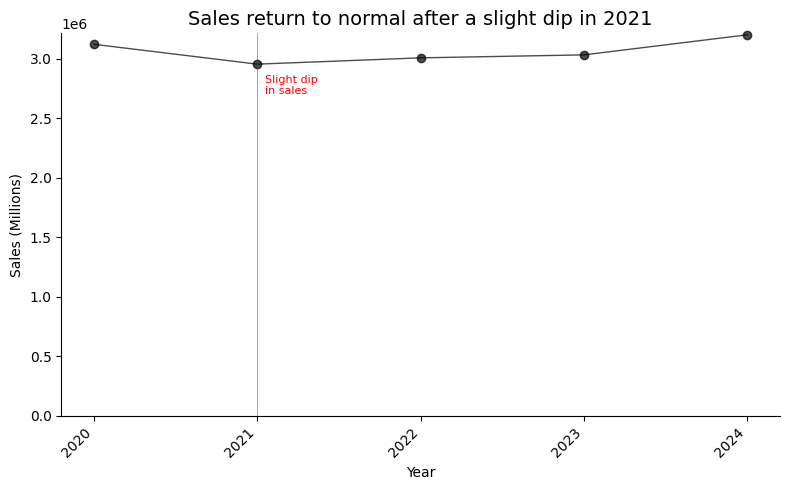

In [168]:
# plt.figure(figsize=(8,5))

# Resource: https://stackoverflow.com/questions/22642511/change-y-range-to-start-from-0-with-matplotlib
# I also had to use chatgpt to figure out why an extra output was happening. using the below formula with `1` in the parentheses in addition to the line above formed two plots, but the first was empty. This is the OOP style:
fig, ax = plt.subplots(figsize=(8,5))

plt.plot(
    subset_sales["Year"],
    subset_sales["Sales"],
    color="black",
    linewidth=1,
    marker="o",
    alpha = .7,
    clip_on=False
    )

ax.set_ylim(bottom=0)
ax.set_xticks(subset_sales['Year'])
# Note about the above: after MUCH searching yielding confusing/unhelpful results, I did ask ChatGPT for help figuring out how to show only the (whole) years shown in the data. This is a much simpler solution than working with datetime.

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.axvline(
    2021,
    color="red",
    linewidth = 0.5,
    alpha = .7
)
ax.text(
    2021+0.05,
    2700000,
    'Slight dip\nin sales',
    color="red",
    fontsize=8
)

plt.title("Sales return to normal after a slight dip in 2021", fontsize=14, color="Black")
plt.xlabel("Year")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45, ha="right",fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

#### Plotting Profit by Year

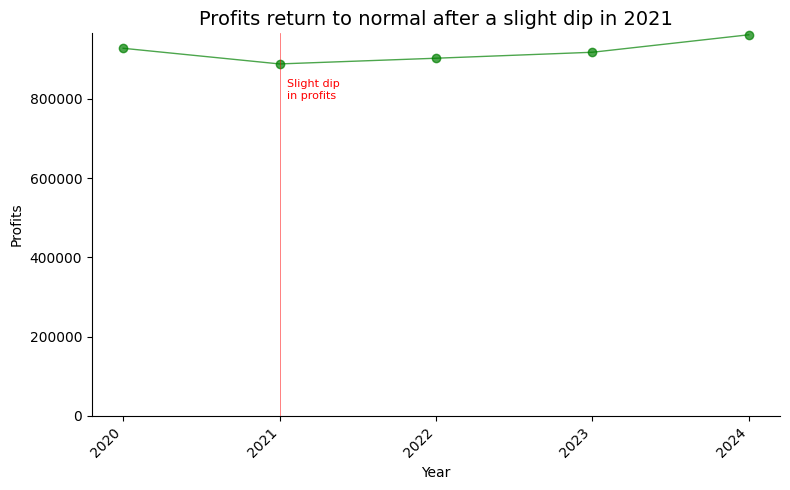

In [169]:
fig, ax = plt.subplots(figsize=(8,5))

plt.plot(
    subset_profit["Year"],
    subset_profit["Profit"],
    color="green",
    linewidth=1,
    marker="o",
    alpha = .7,
    clip_on=False
    )

ax.set_ylim(bottom=0)
ax.set_xticks(subset['Year'])

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.axvline(
    2021,
    color="red",
    linewidth = 0.5,
    alpha = .7
)
ax.text(
    2021+0.05,
    800000,
    'Slight dip\nin profits',
    color="red",
    fontsize=8
)

plt.title("Profits return to normal after a slight dip in 2021", fontsize=14, color="Black")
plt.xlabel("Year")
plt.ylabel("Profits")
plt.xticks(rotation=45, ha="right",fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

#### Notes on Chart 1 Redesign
- **There is no label on the y-axis**
  - I  added a label to the y-axis to more clearly describe the numbers in the data.
- **Y-axis does not start at 0**
  - I fixed the truncated y-axis and started it at 0. This better demonstrates the realistic representation of the changes over the years. 
- **The colors and title are alarmist / inflammatory**
  - I eased the colors, fonts, and line weight back to prevent implying more dire circumstances than the data showed.
- **It looks like the data shown is sales, not profit**
  - The original chart pulled data from the 'Sales' column, but the title referenced profits. I made a chart for each for clearer analysis. 
- I also cleaned the x-axis to show the whole years (as in the data) rather than adding unnecessary markers for half-years and displaying as floats.

*I noted some minor AI usage in my code above.*

### New Chart 2
- Looking at annual sales
- Question: How do total sales compare from 2020-2024?

In [292]:
avg_sales = coffee_df.groupby("Region")["Sales"].mean().reset_index()

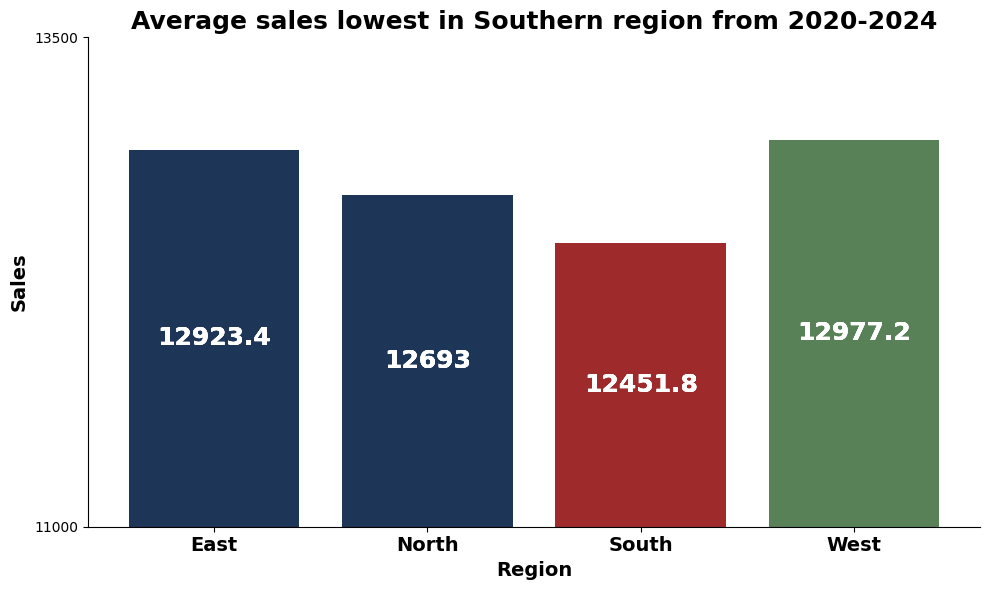

In [ ]:
avg_sales = coffee_df.groupby("Region")["Sales"].mean().reset_index()

colors = ['#1d3557'] * len(avg_sales)

max_index = avg_sales['Sales'].idxmax()
highlight_max_position = avg_sales.index.get_loc(max_index)
colors[highlight_max_position] = "#588157"

min_index = avg_sales['Sales'].idxmin()
highlight_min_position = avg_sales.index.get_loc(min_index)
colors[highlight_min_position] = "#9e2a2b"

fig, ax = plt.subplots(figsize=(10, 6))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#  Add labels to bars
#  Resource: https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html 
for region in avg_sales['Region']:
        p = ax.bar(
                avg_sales["Region"],
                avg_sales["Sales"],
                color=colors
                )
        ax.bar_label(
                p,
                label_type='center',
                color="white",
                fontsize=18,
                fontweight="bold")

plt.title("Average sales lowest in Southern region from 2020-2024", fontsize=18, fontweight="bold")
# plt.grid(True, which='major', color='black', linestyle='-', linewidth=.25)
plt.xlabel("Region", fontsize=14, fontweight="bold")
plt.ylabel("Sales", fontsize=14, fontweight="bold")
plt.ylim(11000, 13500)
plt.xticks(fontsize=14,fontweight="bold")

# Remove y-ticks; reference: https://stackoverflow.com/questions/2176424/hiding-axis-text-in-matplotlib-plots
ax.axes.get_yaxis().set_ticks([11000, 13500])

plt.tight_layout()
plt.show()


#### Notes on Chart 2 redesign
- Very overstimulating colors
  - Muted the color palette
- Too many lines
  - Removed all excess lines and added totals to bars
- Bad contrast of axis labels
  - Removed excess colors
- Exclamation marks!!! and dollar signs $$$
  - Simplified labels
- Column height is very similar, what story is being told?
  - Truncated the y-axis, but kept the bottom and top labels. This allows for closer comparison between the regions without hiding the real data.

In [276]:
regional_sales = coffee_df.groupby(["Year","Region"])["Sales"].mean().reset_index()

sales_east = regional_sales[regional_sales['Region'] == "East"]
sales_north = regional_sales[regional_sales['Region'] == "North"]
sales_south = regional_sales[regional_sales['Region'] == "South"]
sales_west = regional_sales[regional_sales['Region'] == "West"]

sales_east

,Year,Region,Sales
0,2020,East,13544.683333
4,2021,East,12421.083333
8,2022,East,12047.883333
12,2023,East,13750.233333
16,2024,East,12853.000000


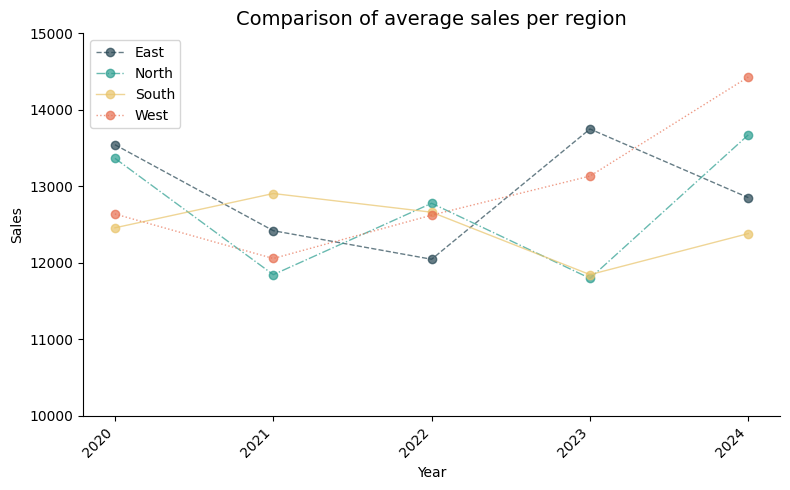

In [291]:
fig, ax = plt.subplots(figsize=(8,5))

# Sunny Beach Day palette from coolors.co 
colors = ["#264653","#2a9d8f","#e9c46a","#e76f51"]

# EAST
plt.plot(
    sales_east["Year"],
    sales_east["Sales"],
    color=colors[0],
    linewidth=1,
    marker="o",
    alpha = .7,
    clip_on=False,
    label='East',
    linestyle = 'dashed'
    )

# NORTH
plt.plot(
    sales_north["Year"],
    sales_north["Sales"],
    color=colors[1],
    linewidth=1,
    marker="o",
    alpha = .7,
    clip_on=False,
    label='North',
    linestyle = "dashdot"
    )

# SOUTH
plt.plot(
    sales_south["Year"],
    sales_south["Sales"],
    color=colors[2],
    linewidth=1,
    marker="o",
    alpha = .7,
    clip_on=False,
    label='South'
    )

# WEST
plt.plot(
    sales_west["Year"],
    sales_west["Sales"],
    color=colors[3],
    linewidth=1,
    marker="o",
    alpha = .7,
    clip_on=False,
    label='West',
    linestyle = "dotted"
    )

ax.set_ylim(bottom=0)
ax.set_xticks(subset['Year'])

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()

plt.title("Comparison of average sales per region", fontsize=14, color="Black")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(rotation=45, ha="right",fontsize=10)
plt.yticks(fontsize=10)

plt.ylim(10000, 15000)

plt.tight_layout()
plt.show()

#### Conclusions can be drawn...
Though the Southern region has the lowest average sales over this 5-year span, they did the best in 2021 before sales declined. It would be good to look into what they did differently that year and what the Western region is doing in later years to grow sales.
It could be good to break down each region's sales by quarter to compare, but that would be getting in the weeds for now!